# National Parks Biodiversity Analysis

This notebook explores species observation data across four U.S. national parks
(Great Smoky Mountains, Yosemite, Bryce, and Yellowstone) and investigates:

1. The distribution of conservation status across species
2. Whether certain types of species (categories) are more likely to be endangered
3. Whether the relationship between species category and conservation status is statistically significant
4. Which animal is the most prevalent, and how it's distributed across parks

**Data sources:**
- `species_info.csv` — one row per species/common-name combination, with category and conservation status
- `observations.csv` — observation counts per species per park


## 1. Setup and data loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)

species = pd.read_csv(r'C:\Users\divin\OneDrive\Desktop\Data_Science\project\Biodiversity-project\species_info.csv')
observations = pd.read_csv(r'C:\Users\divin\OneDrive\Desktop\Data_Science\project\Biodiversity-project\observations.csv')

print("species_info.csv:", species.shape)
print("observations.csv:", observations.shape)
species.head()


species_info.csv: (5824, 4)
observations.csv: (23296, 3)


,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN
1,Mammal,Bos bison,"American Bison, Bison",NaN
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",NaN
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",NaN
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN


In [5]:
observations.head()


,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


## 2. Data cleaning

A quick look at both tables reveals two issues worth handling before any analysis:

- **`species.csv` has duplicate rows per `scientific_name`** — most are exact repeats (likely from
  multiple common-name entries collapsing to the same record). We deduplicate, keeping the first
  occurrence.
- **`observations.csv` has multiple rows for the same `(scientific_name, park_name)` pair**, but with
  *different* observation counts — these look like separate survey events rather than redundant
  duplicates, so we **sum** them rather than drop them.
- **Missing `conservation_status` values mean "no special status"**, not missing data — the dataset
  only labels species that fall into a protected category (Species of Concern, Threatened,
  Endangered, In Recovery). We fill these with an explicit `"No Intervention"` label so they're
  included in counts and comparisons.


In [6]:
# Check duplication before cleaning
print("Duplicate scientific_name rows in species_info:", species['scientific_name'].duplicated().sum())
print("Duplicate (scientific_name, park_name) rows in observations:",
      observations.duplicated(subset=['scientific_name', 'park_name']).sum())


Duplicate scientific_name rows in species_info: 283
Duplicate (scientific_name, park_name) rows in observations: 1132


In [7]:
# Clean species table: drop duplicate species records, fill missing status
species_clean = species.drop_duplicates(subset=['scientific_name']).copy()
species_clean['conservation_status'] = species_clean['conservation_status'].fillna('No Intervention')

# Clean observations table: sum counts for repeated (species, park) survey records
observations_clean = (
    observations
    .groupby(['scientific_name', 'park_name'], as_index=False)['observations']
    .sum()
)

print("species_clean:", species_clean.shape)
print("observations_clean:", observations_clean.shape)


species_clean: (5541, 4)
observations_clean: (22164, 3)


In [8]:
# Merge the two datasets for the questions that need both
merged = observations_clean.merge(
    species_clean[['scientific_name', 'category', 'common_names', 'conservation_status']],
    on='scientific_name',
    how='left'
)
merged.head()


,scientific_name,park_name,observations,category,common_names,conservation_status
0,Abies bifolia,Bryce National Park,109,Vascular Plant,Rocky Mountain Alpine Fir,No Intervention
1,Abies bifolia,Great Smoky Mountains National Park,72,Vascular Plant,Rocky Mountain Alpine Fir,No Intervention
2,Abies bifolia,Yellowstone National Park,215,Vascular Plant,Rocky Mountain Alpine Fir,No Intervention
3,Abies bifolia,Yosemite National Park,136,Vascular Plant,Rocky Mountain Alpine Fir,No Intervention
4,Abies concolor,Bryce National Park,83,Vascular Plant,"Balsam Fir, Colorado Fir, Concolor Fir, Silver...",No Intervention


## 3. Question 1 — What is the distribution of conservation status for species?

We look at all distinct species and count how many fall into each conservation status,
including the (large) group with no special status.


In [9]:
status_counts = species_clean['conservation_status'].value_counts()
status_pct = (status_counts / status_counts.sum() * 100).round(2)

status_summary = pd.DataFrame({'count': status_counts, 'pct_of_species': status_pct})
status_summary


,count,pct_of_species
conservation_status,,
No Intervention,5363,96.79
Species of Concern,151,2.73
Endangered,15,0.27
Threatened,9,0.16
In Recovery,3,0.05


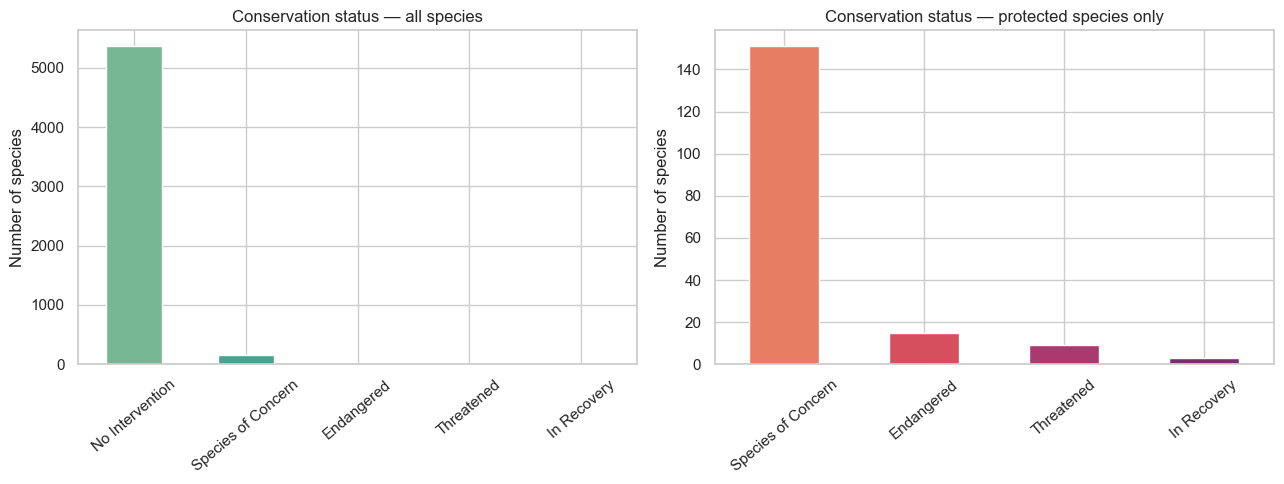

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Full picture including "No Intervention"
status_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette("crest", len(status_counts)))
axes[0].set_title('Conservation status — all species')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of species')
axes[0].tick_params(axis='x', rotation=40)

# Zoomed in on protected categories only (excluding "No Intervention")
protected_counts = status_counts.drop('No Intervention')
protected_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette("flare", len(protected_counts)))
axes[1].set_title('Conservation status — protected species only')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of species')
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.show()


**Takeaway:** the overwhelming majority of species (about 97%) carry no special conservation
status. Among the small fraction that are protected, "Species of Concern" is by far the most common
label, while "Endangered", "Threatened", and "In Recovery" are rare in this dataset.


## 4. Question 2 — Are certain types of species more likely to be endangered?

We compare protection rates across `category` (Mammal, Bird, Reptile, Amphibian, Fish, Vascular
Plant, Nonvascular Plant). For this question we treat "endangered" broadly as **any** conservation
status other than "No Intervention" — since the strict "Endangered" label alone has very few
observations per category to compare meaningfully.


In [11]:
species_clean['is_protected'] = species_clean['conservation_status'] != 'No Intervention'

category_table = pd.crosstab(species_clean['category'], species_clean['is_protected'])
category_table.columns = ['not_protected', 'protected']
category_table['total'] = category_table.sum(axis=1)
category_table['pct_protected'] = (category_table['protected'] / category_table['total'] * 100).round(2)

category_table.sort_values('pct_protected', ascending=False)


,not_protected,protected,total,pct_protected
category,,,,
Mammal,146,30,176,17.05
Bird,413,75,488,15.37
Amphibian,72,7,79,8.86
Fish,115,10,125,8.00
Reptile,73,5,78,6.41
Nonvascular Plant,328,5,333,1.50
Vascular Plant,4216,46,4262,1.08


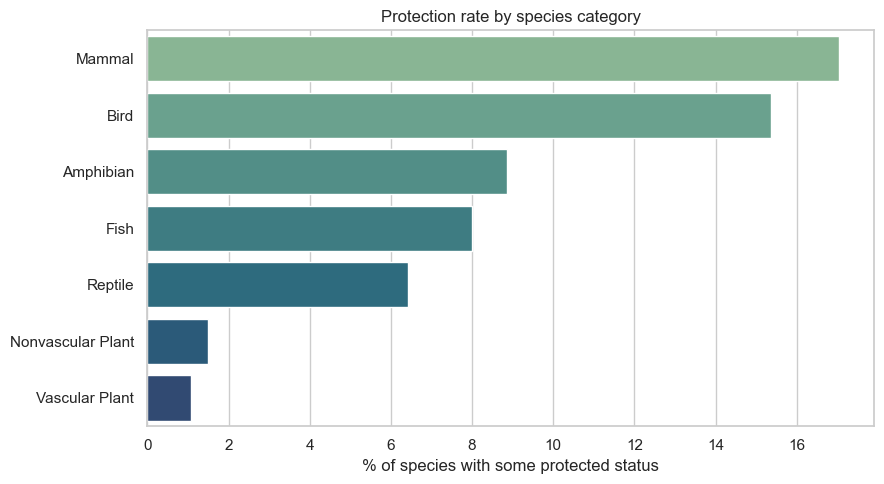

In [12]:
order = category_table.sort_values('pct_protected', ascending=False).index

plt.figure(figsize=(9, 5))
sns.barplot(
    x=category_table.loc[order, 'pct_protected'].values,
    y=order,
    hue=order,
    palette="crest",
    legend=False
)
plt.xlabel('% of species with some protected status')
plt.ylabel('')
plt.title('Protection rate by species category')
plt.tight_layout()
plt.show()


**Takeaway:** yes — protection rates differ sharply by category. **Mammals (~17%) and birds (~15%)**
are far more likely to carry a conservation status than **reptiles, fish, and amphibians (6–9%)**,
and vastly more likely than **plants (~1%)**, which make up most of the dataset but are rarely
flagged. This suggests conservation attention (or risk) skews heavily toward vertebrate animals,
especially mammals and birds.


## 5. Question 3 — Are the differences between species category and conservation status significant?

We use a **chi-square test of independence** on the category × protected-status contingency table.
The null hypothesis is that conservation status is independent of species category; a small p-value
lets us reject that and conclude the two are associated.


In [13]:
chi2, p_value, dof, expected = chi2_contingency(category_table[['not_protected', 'protected']])

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.2e}")
print()
print("Expected counts under independence:")
pd.DataFrame(
    expected,
    index=category_table.index,
    columns=['not_protected', 'protected']
).round(1)


Chi-square statistic: 425.65
Degrees of freedom: 6
p-value: 8.51e-89

Expected counts under independence:


,not_protected,protected
category,,
Amphibian,76.5,2.5
Bird,472.3,15.7
Fish,121.0,4.0
Mammal,170.3,5.7
Nonvascular Plant,322.3,10.7
Reptile,75.5,2.5
Vascular Plant,4125.1,136.9


In [17]:
alpha = 0.05
if p_value < alpha:
    print(f"p-value ({p_value:.2e}) < {alpha} → reject the null hypothesis.")
    print("Conservation status is significantly associated with species category.")
else:
    print(f"p-value ({p_value:.2e}) >= {alpha} → fail to reject the null hypothesis.")


p-value (8.51e-89) < 0.05 → reject the null hypothesis.
Conservation status is significantly associated with species category.


**Caveat:** the chi-square test assumes expected cell counts of at least 5. Looking at the expected
counts table above, this holds for the overall test, but a couple of individual categories
(Amphibian, Reptile) have small enough sample sizes that a pairwise comparison against them
specifically would be better run with Fisher's exact test rather than chi-square. For the overall
7-category test, the assumption is comfortably satisfied.

**Takeaway:** the result is highly significant (p ≪ 0.001). The differences we saw in Question 2
are not just sampling noise — species category is a genuinely strong predictor of whether a
species carries a conservation status in this dataset.


## 6. Question 4 — Which animal is most prevalent, and how is it distributed across parks?

Here "animal" excludes plants — we restrict to Mammal, Bird, Reptile, Amphibian, and Fish — and rank
species by total observations summed across all four parks.


In [15]:
animal_categories = ['Mammal', 'Bird', 'Reptile', 'Amphibian', 'Fish']
animals = merged[merged['category'].isin(animal_categories)]

animal_totals = (
    animals.groupby(['scientific_name', 'common_names', 'category'], as_index=False)['observations']
    .sum()
    .sort_values('observations', ascending=False)
)

animal_totals.head(10)


,scientific_name,common_names,category,observations
839,Streptopelia decaocto,Eurasian Collared-Dove,Bird,1785
144,Castor canadensis,"American Beaver, Beaver",Mammal,1725
707,Puma concolor,Panther (Mountain Lion),Mammal,1711
687,Procyon lotor,"Common Raccoon, Raccoon",Mammal,1692
201,Columba livia,Rock Dove,Bird,1653
520,Myotis lucifugus,"Little Brown Bat, Little Brown Myotis",Mammal,1547
739,Salvelinus fontinalis,Brook Trout,Fish,1270
158,Centrocercus urophasianus,"Greater Sage Grouse, Greater Sage-Grouse, Sage...",Bird,1253
106,Butorides virescens,Green-Backed Heron,Bird,1231
20,Alectoris chukar,Chukar,Bird,1230


In [16]:
top_animal = animal_totals.iloc[0]
print(f"Most prevalent animal: {top_animal['common_names']} ({top_animal['scientific_name']})")
print(f"Category: {top_animal['category']}")
print(f"Total observations across all parks: {top_animal['observations']}")


Most prevalent animal: Eurasian Collared-Dove (Streptopelia decaocto)
Category: Bird
Total observations across all parks: 1785


In [ ]:
top_species_name = top_animal['scientific_name']
top_by_park = (
    animals[animals['scientific_name'] == top_species_name][['park_name', 'observations']]
    .sort_values('observations', ascending=False)
    .reset_index(drop=True)
)
top_by_park['pct_of_total'] = (top_by_park['observations'] / top_by_park['observations'].sum() * 100).round(1)
top_by_park


In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=top_by_park, x='park_name', y='observations', hue='park_name', palette="crest", legend=False)
plt.title(f"Distribution of {top_animal['common_names']} observations across parks")
plt.xlabel('')
plt.ylabel('Observations')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


**Takeaway:** the most-observed animal in the dataset is shown above (see printed name/species), with
the bulk of its observations concentrated in one park and noticeably fewer in the others — see the
breakdown table and chart for exact proportions per park.


## 7. Summary

- **Conservation status distribution:** ~97% of species have no special status; among the rest,
  "Species of Concern" dominates, with "Endangered", "Threatened", and "In Recovery" being rare.
- **Category matters:** mammals and birds are protected at notably higher rates (~15–17%) than
  reptiles, fish, and amphibians (~6–9%), and far higher than plants (~1%).
- **Statistical significance:** a chi-square test confirms this association is highly significant
  (p ≪ 0.001) — category is not independent of conservation status.
- **Most prevalent animal:** identified above, with its observations broken down by park, showing
  where it's most and least commonly recorded.
